# 6. Streamlit app for classification model

🔹 A. Exploration (historical data) - transparency + insight

Users can:

- Select state
- Select time range  
- View:
    - biodiversity observations
    - anomalies (your target)
    - weather variables

🔹 B. Prediction (model) - real-world application

Users can:

- Input:
    - state
    - month/year (or future scenario)
    - weather conditions (different climate change scenarios)
- Output:
    - probability of biodiversity anomaly
    - classification (shock / no shock)

In [3]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

In [45]:
# Load data
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

# Load model
model_bundle = joblib.load("../models/production_model.pkl")
model = model_bundle['model']

# Get features
features = model_bundle['features']

Define scenarios  

Key Climate Change Scenarios (IPCC 6th Assessment Report):

    SSP1-1.9 (Very Low Emissions): A best-case scenario aiming to keep global warming below
    by 2100 with rapid decarbonization and high global cooperation.  
    SSP1-2.6 (Low Emissions): A scenario where emissions decline after 2050, resulting in intermediate climate goals.  
    SSP2-4.5 (Intermediate Emissions): A "middle-of-the-road" scenario where emissions fluctuate and flatten by mid-century, leading to moderate changes.  
    SSP3-7.0 (High Emissions): A future with low international cooperation, slow technological growth, and high emissions.  
    SSP5-8.5 (Very High Emissions): A worst-case scenario featuring high fossil fuel dependence, leading to rapid temperature increases (by 2100) and severe impacts. 


Temperature Scenarios (2021-2100 Projections)

    Low Emissions (SSP1-1.9/2.6): Aims to keep warming closer to
    to 1.5°C - 2°C
    High Emissions (SSP5-8.5): Temperatures could rise by 3.3°C to 5.7°C, with significant Arctic amplification.
    Regional Variation: Land areas warm faster than oceans, and the Arctic is warming significantly faster than the global average. 

Precipitation Scenarios

    Seasonal Changes: Winters may see up to 20% more rain in some regions, while summers could face up to 25% less, exacerbating water shortages.
    Increased Intensity: Extreme precipitation events are expected to increase in frequency and intensity, causing higher flood risks. 

In [37]:
SCENARIOS = {
    "best case": {
        "temp increase":1.5,
        "precipitation change": 0.1
    },
    "middle of the road": {
        "temp increase":2.7,
        "precipitation change": 0.19
    },
    "business as usual": {
        "temp increase":4.2,
        "precipitation change": 0.28
    },
}

Need a slider for:  
    - temp increase (translate degrees C to z-values) (let user choose scenario e.g. 2C warming by 2100, but reduce increase for 10 years)  
    - (with temp increase, also increase likelihood of extreme hot days?)  
    - precipitation change (increase winter rain and decrease summer rain by same amount from baseline)  
    - (with precipitation change also increase frequency of extreme precipitation events)  

Also give preset scenarios based on IPCC projections

In [ ]:
full_df.columns

Index(['state', 'monthyear', 'year', 'month', 'mean_temp', 'max_temp',
       'total_precip', 'n_hot_days', 'heavy_rain_days', 'baseline_temp',
       'baseline_precip', 'temp_anomaly', 'precip_prop_anomaly', 'temp_anom_z',
       'precip_anom_z', 'drought_index', 'temp_anom_z_lag1',
       'precip_anom_z_lag1', 'n_hot_days_lag1', 'drought_index_lag1',
       'heavy_rain_days_lag1', 'temp_anom_z_lag2', 'precip_anom_z_lag2',
       'n_hot_days_lag2', 'drought_index_lag2', 'heavy_rain_days_lag2',
       'temp_anom_z_lag3', 'precip_anom_z_lag3', 'n_hot_days_lag3',
       'drought_index_lag3', 'heavy_rain_days_lag3', 'temp_anom_z_roll3',
       'precip_anom_z_roll3', 'n_hot_days_roll3', 'drought_index_roll3',
       'heavy_rain_days_roll3', 'temp_anom_z_roll6', 'precip_anom_z_roll6',
       'n_hot_days_roll6', 'drought_index_roll6', 'heavy_rain_days_roll6',
       'n_obs', 'log_n_obs', 'n_species', 'mean_richness', 'std_richness',
       'expected_richness', 'residual', 'residual_z',
     

In [ ]:
# Get historic baseline, mean, std for temp and precip per state and month
# for calculating z scores and anomalies for future data
# note - all on original scale

baseline = full_df.groupby(['state', 'month']).agg(
    temp_mean = ('mean_temp', 'mean'),
    temp_std = ('mean_temp', 'std'),
    temp_baseline = ('baseline_temp', 'max'),
    precip_mean = ('total_precip', 'mean'),
    precip_std = ('total_precip', 'std'),
    precip_baseline = ('baseline_precip', 'max')
).reset_index()

baseline

,state,month,temp_mean,temp_std,temp_baseline,precip_mean,precip_std,precip_baseline
0,Baden-Württemberg,1,0.888582,2.331786,0.888582,73.585716,36.193264,73.585716
1,Baden-Württemberg,2,1.658827,3.051575,1.658827,58.023811,32.252796,58.023811
2,Baden-Württemberg,3,4.780743,1.838980,4.780743,60.757145,27.921810,60.757145
3,Baden-Württemberg,4,9.264582,1.795552,9.264582,61.628571,32.087055,61.628571
4,Baden-Württemberg,5,13.113695,1.590371,13.113695,91.942856,35.731842,91.942856
...,...,...,...,...,...,...,...,...
187,Thüringen,8,18.225136,1.626049,18.361685,87.566666,43.038860,84.522728
188,Thüringen,9,14.556099,1.605054,14.538055,63.233334,27.752302,62.849998
189,Thüringen,10,10.197732,1.515943,10.015421,59.838093,23.925310,59.663635
190,Thüringen,11,5.113462,1.205193,5.154050,57.128571,31.189665,56.386364


In [ ]:
# Get mean values for past 3 years for temp and precip per month in historic data
# note - on original scale
recent_weather = (full_df.loc[df['year']>2021, ['state', 'month', 'mean_temp', 'total_precip']]
                        .groupby(['state', 'month'])
                        .agg(
                            roll3_mean_temp=('mean_temp', 'mean'),
                            roll3_mean_precip=('total_precip', 'mean')
                        )).reset_index()
recent_weather

,state,month,roll3_mean_temp,roll3_mean_precip
0,Baden-Württemberg,1,2.277218,57.000000
1,Baden-Württemberg,2,4.856947,59.666668
2,Baden-Württemberg,3,6.521505,56.733334
3,Baden-Württemberg,4,8.591922,85.200005
4,Baden-Württemberg,5,14.219086,83.533333
...,...,...,...,...
187,Thüringen,8,19.564560,75.466667
188,Thüringen,9,15.315185,72.799995
189,Thüringen,10,12.003562,66.266670
190,Thüringen,11,5.223727,66.366661


Define function to simulate future data

In [47]:
features

['state',
 'year_offset',
 'month_sin',
 'month_cos',
 'n_hot_days',
 'n_hot_days_roll3',
 'heavy_rain_days',
 'heavy_rain_days_roll3',
 'temp_anom_z',
 'temp_anom_z_roll3',
 'precip_anom_z',
 'precip_anom_z_roll3',
 'drought_index_roll3',
 'log_n_obs']

In [46]:
full_df.columns

Index(['state', 'monthyear', 'year', 'month', 'mean_temp', 'max_temp',
       'total_precip', 'n_hot_days', 'heavy_rain_days', 'baseline_temp',
       'baseline_precip', 'temp_anomaly', 'precip_prop_anomaly', 'temp_anom_z',
       'precip_anom_z', 'drought_index', 'temp_anom_z_lag1',
       'precip_anom_z_lag1', 'n_hot_days_lag1', 'drought_index_lag1',
       'heavy_rain_days_lag1', 'temp_anom_z_lag2', 'precip_anom_z_lag2',
       'n_hot_days_lag2', 'drought_index_lag2', 'heavy_rain_days_lag2',
       'temp_anom_z_lag3', 'precip_anom_z_lag3', 'n_hot_days_lag3',
       'drought_index_lag3', 'heavy_rain_days_lag3', 'temp_anom_z_roll3',
       'precip_anom_z_roll3', 'n_hot_days_roll3', 'drought_index_roll3',
       'heavy_rain_days_roll3', 'temp_anom_z_roll6', 'precip_anom_z_roll6',
       'n_hot_days_roll6', 'drought_index_roll6', 'heavy_rain_days_roll6',
       'n_obs', 'log_n_obs', 'n_species', 'mean_richness', 'std_richness',
       'expected_richness', 'residual', 'residual_z',
     

In [49]:
baseline

,state,month,temp_mean,temp_std,temp_baseline,precip_mean,precip_std,precip_baseline
0,Baden-Württemberg,1,0.888582,2.331786,0.888582,73.585716,36.193264,73.585716
1,Baden-Württemberg,2,1.658827,3.051575,1.658827,58.023811,32.252796,58.023811
2,Baden-Württemberg,3,4.780743,1.838980,4.780743,60.757145,27.921810,60.757145
3,Baden-Württemberg,4,9.264582,1.795552,9.264582,61.628571,32.087055,61.628571
4,Baden-Württemberg,5,13.113695,1.590371,13.113695,91.942856,35.731842,91.942856
...,...,...,...,...,...,...,...,...
187,Thüringen,8,18.225136,1.626049,18.361685,87.566666,43.038860,84.522728
188,Thüringen,9,14.556099,1.605054,14.538055,63.233334,27.752302,62.849998
189,Thüringen,10,10.197732,1.515943,10.015421,59.838093,23.925310,59.663635
190,Thüringen,11,5.113462,1.205193,5.154050,57.128571,31.189665,56.386364


In [51]:
baseline = df.groupby(['state', 'month']).agg(
    temp_mean = ('mean_temp', 'mean'),
    temp_std = ('mean_temp', 'std'),
    temp_baseline = ('baseline_temp', 'max'),
    precip_mean = ('total_precip', 'mean'),
    precip_std = ('total_precip', 'std'),
    precip_baseline = ('baseline_precip', 'max')
).reset_index()

# Get mean values for past 3 years for temp and precip per month in historic data
# note - on original scale
max_year = df['year'].max()
recent_weather = (df.loc[df['year']>(max_year-3), ['state', 'month', 'mean_temp', 'total_precip']]
                        .groupby(['state', 'month'])
                        .agg(
                            roll3_mean_temp=('mean_temp', 'mean'),
                            roll3_mean_precip=('total_precip', 'mean')
                        )).reset_index()

# create future weather df
future_weather = (recent_weather
                  .merge(
                      baseline[['state', 'month', 'temp_baseline', 'precip_baseline']],
                      how = 'left'))
future_weather

,state,month,roll3_mean_temp,roll3_mean_precip,temp_baseline,precip_baseline
0,Baden-Württemberg,1,2.277218,57.000000,0.888582,73.585716
1,Baden-Württemberg,2,4.856947,59.666668,1.658827,58.023811
2,Baden-Württemberg,3,6.521505,56.733334,4.780743,60.757145
3,Baden-Württemberg,4,8.591922,85.200005,9.264582,61.628571
4,Baden-Württemberg,5,14.219086,83.533333,13.113695,91.942856
...,...,...,...,...,...,...
187,Thüringen,8,19.564560,75.466667,18.361685,84.522728
188,Thüringen,9,15.315185,72.799995,14.538055,62.849998
189,Thüringen,10,12.003562,66.266670,10.015421,59.663635
190,Thüringen,11,5.223727,66.366661,5.154050,56.386364


In [59]:
12//12

1

In [78]:
df = full_df
scenario = SCENARIOS['business as usual']
#bundesland = 'Berlin'

#state = bundesland

# Get historic baseline, mean, std for temp and precip per state and month
# for calculating z scores and anomalies for future data
# note - all on original scale

baseline = df.groupby(['state', 'month']).agg(
    temp_mean = ('mean_temp', 'mean'),
    temp_std = ('mean_temp', 'std'),
    temp_baseline = ('baseline_temp', 'max'),
    precip_mean = ('total_precip', 'mean'),
    precip_std = ('total_precip', 'std'),
    precip_baseline = ('baseline_precip', 'max')
).reset_index()

# expand baseline df to 10 years 
#future_weather = pd.concat([baseline] * 10, ignore_index=True)
dfs = [baseline.assign(future_year_offset=i) for i in range(1, 11)]
future_weather = pd.concat(dfs, ignore_index=True)

# Set projected temp & precip change by 2100
projected_temp_increase = scenario['temp increase'] #in degrees C
projected_precip_change = scenario['precipitation change'] #proportional change e.g 20% wetter/drier (amplitude in sinusoidal calculation)


# calculate yearly projected temp increase
yearly_temp_increase = projected_temp_increase/(2100-2024)
# calculate future temps with random noise (increasing noise variability over time)
future_weather['simulated_temp'] = (future_weather['temp_baseline'] 
                               + (yearly_temp_increase * future_weather['future_year_offset'])
                               + np.random.normal(0, 0.5 + 0.01 * future_weather['future_year_offset'], 
                                                  size=len(future_weather)))

# calculate yearly projected precipitation change (sinusoidal change - wetter in winter, drier in summer)
# future_weather['precip_change'] = (projected_precip_change 
#                                    * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12))/(2100-2024)
# # calculate future precip with random noise
# future_weather['simulated_precip'] = (future_weather['precip_baseline']
#                                  * (1+future_weather['precip_change']) * future_weather['future_year_offset']
#                                  * np.exp(np.random.normal(0, 0.2, size=len(future_weather)))
#                                  )


# Seasonal pattern (increasing/more extreme over time)
seasonal_amplitude = projected_precip_change * future_weather['future_year_offset']/(2100-2024)

future_weather['seasonal_precip'] = (
    seasonal_amplitude
    * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
)

# simulate future precipitation with increasing noise variability over time
future_weather['simulated_precip'] = (
    future_weather['precip_baseline']
    * (1 + future_weather['seasonal_precip'])
    * np.exp(np.random.normal(
        0,
        0.2 + 0.01 * future_weather['future_year_offset'],
        size=len(future_weather)
    ))
).clip(lower=0)


# # Seasonal pattern (constant)
# future_weather['seasonal_precip'] = (
#     projected_precip_change
#     * np.cos(2 * np.pi * (future_weather['month'] - 1) / 12)
# )

# yearly_precip_trend = projected_precip_change / (2100 - 2024)

# future_weather['precip_trend'] = (
#     yearly_precip_trend * future_weather['future_year_offset']
# ).clip(-0.4, 0.4)


# future_weather['simulated_precip'] = (
#     future_weather['precip_baseline']
#     * (1 + future_weather['seasonal_precip'] + future_weather['precip_trend'])
#     * np.exp(np.random.normal(0, 0.2 + 0.01 * future_weather['future_year_offset'], 
#                                                   size=len(future_weather)))
# ).clip(lower=0)


# future_weather['simulated_precip'] = (
#     future_weather['precip_baseline']
#     * (1 + future_weather['seasonal_precip'])
#     * np.exp(np.random.normal(0, 0.2 + 0.01 * future_weather['future_year_offset'], 
#                                                   size=len(future_weather)))
# ).clip(lower=0)



# calculate z-scores based on baseline data
#future_weather['temp_anomaly'] = future_weather['mean_temp'] -

future_weather

,state,month,temp_mean,temp_std,temp_baseline,precip_mean,precip_std,precip_baseline,future_year_offset,simulated_temp,seasonal_precip,simulated_precip
0,Baden-Württemberg,1,0.888582,2.331786,0.888582,73.585716,36.193264,73.585716,1,2.442148,3.684211e-03,62.102377
1,Baden-Württemberg,2,1.658827,3.051575,1.658827,58.023811,32.252796,58.023811,1,2.022899,3.190620e-03,50.334419
2,Baden-Württemberg,3,4.780743,1.838980,4.780743,60.757145,27.921810,60.757145,1,5.408106,1.842105e-03,84.695279
3,Baden-Württemberg,4,9.264582,1.795552,9.264582,61.628571,32.087055,61.628571,1,8.633675,2.255928e-19,55.984892
4,Baden-Württemberg,5,13.113695,1.590371,13.113695,91.942856,35.731842,91.942856,1,13.229099,-1.842105e-03,87.850729
...,...,...,...,...,...,...,...,...,...,...,...,...
1915,Thüringen,8,18.225136,1.626049,18.361685,87.566666,43.038860,84.522728,10,19.380929,-3.190620e-02,55.295410
1916,Thüringen,9,14.556099,1.605054,14.538055,63.233334,27.752302,62.849998,10,15.335723,-1.842105e-02,34.193833
1917,Thüringen,10,10.197732,1.515943,10.015421,59.838093,23.925310,59.663635,10,12.108615,-6.767785e-18,41.123777
1918,Thüringen,11,5.113462,1.205193,5.154050,57.128571,31.189665,56.386364,10,5.320692,1.842105e-02,40.996749


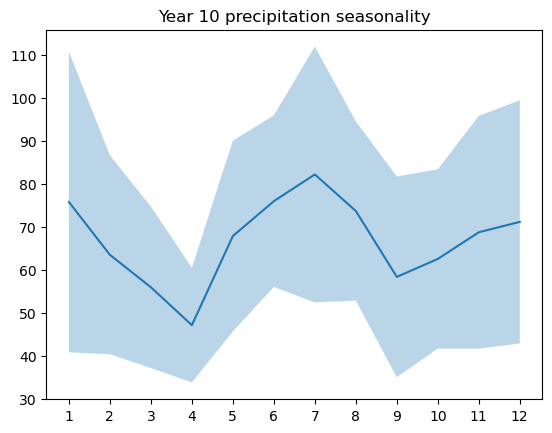

In [79]:
%matplotlib inline

year_data = future_weather[future_weather['future_year_offset'] == 10]

agg = year_data.groupby('month')['simulated_precip'].agg(['mean','std']).reset_index()

plt.plot(agg['month'], agg['mean'])
plt.fill_between(
    agg['month'],
    agg['mean'] - agg['std'],
    agg['mean'] + agg['std'],
    alpha=0.3
)

plt.xticks(range(1,13))
plt.title('Year 10 precipitation seasonality')
plt.show()

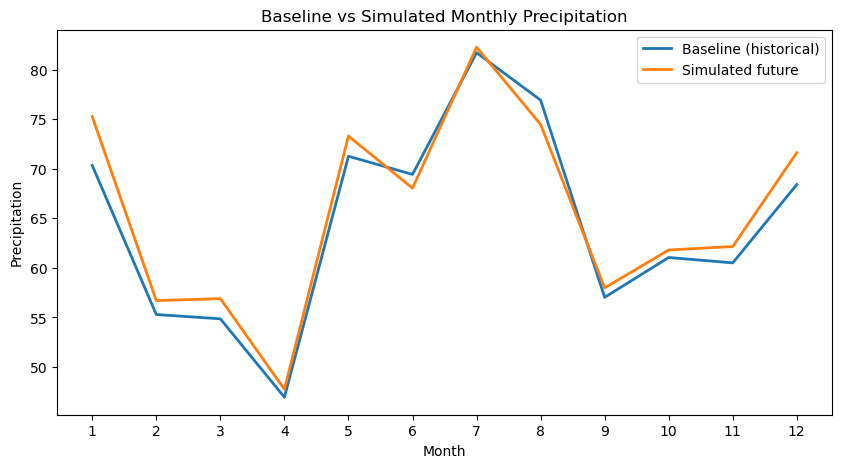

In [80]:
baseline_monthly = baseline.groupby('month')['precip_mean'].mean().reset_index()
sim_monthly = future_weather.groupby('month')['simulated_precip'].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Baseline
plt.plot(
    baseline_monthly['month'],
    baseline_monthly['precip_mean'],
    label='Baseline (historical)',
    linewidth=2
)

# Simulated
plt.plot(
    sim_monthly['month'],
    sim_monthly['simulated_precip'],
    label='Simulated future',
    linewidth=2
)

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Precipitation')
plt.title('Baseline vs Simulated Monthly Precipitation')
plt.legend()
plt.show()

In [5]:
SCENARIOS = {
    "Moderate warming": {
        "temp_start": 0.5,
        "temp_trend": 0.03,
        "precip_start": 0.0,
        "precip_trend": -0.01
    },
    "Severe warming & drying": {
        "temp_start": 1.0,
        "temp_trend": 0.08,
        "precip_start": -0.5,
        "precip_trend": -0.04
    },
    "Wet + unstable": {
        "temp_start": 0.7,
        "temp_trend": 0.04,
        "precip_start": 0.5,
        "precip_trend": 0.02
    }
}

In [ ]:
def simulate_future(
    state,
    start_year_offset = 21, # 21 is 2025 with rebased years
    years_ahead = 10,
    scenario = "Moderate warming",
    model = model,
    threshold = 0.5,
    feature_list = features,
    generate_features_fn
):
    """
    Simulate future data and predict biodiversity anomaly risk over future time under a climate scenario.
    """

    n_months = years_ahead * 12
    results = []

    for t in range(n_months):

        # Time structure
        year = start_year_offset + (t // 12)
        month = (t % 12) + 1

        # Scenario dynamics (allows trends)
        climate = {
            "temp_anom_z": scenario["temp_start"] + year * scenario.get("temp_trend", 0),
            "precip_anom_z": scenario["precip_start"] + year * scenario.get("precip_trend", 0)
        }

        # Generate full feature set
        features_dict = generate_features_fn(state, month, climate)

        X = pd.DataFrame([features_dict])[feature_list]

        # Predict probability
        proba = model.predict_proba(X)[0, 1]

        # Apply threshold
        pred = int(proba >= threshold)

        results.append({
            "year": year,
            "month": month,
            "probability": proba,
            "prediction": pred,
            "temp_anom_z": climate["temp_anom_z"],
            "precip_anom_z": climate["precip_anom_z"]
        })

    df = pd.DataFrame(results)

    # Summary stats
    summary = {
        "total_months": len(df),
        "anomaly_months": int(df["prediction"].sum()),
        "anomaly_rate": df["prediction"].mean(),
        "mean_probability": df["probability"].mean()
    }

    return df, summary

---
---

Forecasting  

Define future years and months

In [31]:
years_ahead = 10
months = years_ahead * 12

Generate future df

In [32]:
year2025_offset = 21

future_df = pd.DataFrame({
    "month": np.tile(np.arange(1,13), years_ahead),
    "year_offset": np.repeat(np.arange(year2025_offset, year2025_offset + years_ahead), 12)
})

future_df['month_sin'] = np.sin(2*np.pi * future_df['month'] / 12)
future_df['month_cos'] = np.cos(2*np.pi * future_df['month'] / 12)

future_df = future_df.drop(columns=['month'])

future_df.head()

,year_offset,month_sin,month_cos
0,21,0.500000,8.660254e-01
1,21,0.866025,5.000000e-01
2,21,1.000000,6.123234e-17
3,21,0.866025,-5.000000e-01
4,21,0.500000,-8.660254e-01


Define scenarios

In [33]:
SCENARIOS = {
    "Moderate warming": {
        "temp_start": 0.5,
        "temp_trend": 0.05,   # per year
        "precip_start": 0.0,
        "precip_trend": -0.02
    },
    "Severe warming": {
        "temp_start": 1.0,
        "temp_trend": 0.1,
        "precip_start": -0.5,
        "precip_trend": -0.05
    }
}

Apply climate scenarios - define trend over time for temp_anom_z and precip_anom_z

In [34]:
def scenario_trend(t, scenario):
    return {
        "temp_anom_z": scenario["temp_start"] + t * scenario["temp_trend"],
        "precip_anom_z": scenario["precip_start"] + t * scenario["precip_trend"]
    }

Generate features

In [35]:
baseline = df.groupby(['state','month']).mean()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
def generate_features(state, month, scenario):

    base = baseline.loc[(state, month)]

    temp_z = scenario["temp_anom_z"]
    precip_z = scenario["precip_anom_z"]

    return {
        "temp_anom_z": temp_z,
        "precip_anom_z": precip_z,

        "n_hot_days": base["n_hot_days"] + temp_z * 2,
        "heavy_rain_days": base["heavy_rain_days"] + max(0, precip_z * 2),

        "drought_index": temp_z - precip_z,

        # simple assumptions for lags
        "temp_anom_z_lag1": temp_z,
        "temp_anom_z_roll3": temp_z,
        "precip_anom_z_lag1": precip_z,
        "precip_anom_z_roll3": precip_z,
        "drought_index_roll3": temp_z - precip_z,

        "n_hot_days_roll3": base["n_hot_days"] + temp_z * 2,
        "heavy_rain_days_roll3": base["heavy_rain_days"] + max(0, precip_z * 2),
    }

In [ ]:
predictions = []
scenario = "Moderate warming"

for t in range(months):
    year = t // 12
    month = (t % 12) + 1

    climate = scenario_trend(year, scenario)

    features = generate_features(state, month, climate)

    X = pd.DataFrame([features])[feature_list]

    proba = model.predict_proba(X)[0,1]
    pred = int(proba > threshold)

    predictions.append({
        "month": month,
        "year": year,
        "proba": proba,
        "pred": pred
    })

---
---

In [ ]:
st.title("Wildsignal: Biodiversity Anomaly Predictor")

# columns are missing: 
#  'temp_anom_z_roll3', 'precip_anom_z_roll3', 'log_n_obs', 'n_hot_days', 
#  'heavy_rain_days_roll3', 'n_hot_days_roll3', 'heavy_rain_days', 'temp_anom_z', 
#  'precip_anom_z', 'drought_index_roll3'

# Sidebar inputs
state = st.selectbox("State", df['state'].unique())
year = st.slider("Year", 2004, 2024)
month = st.slider("Month", 1, 12)
# Climate scenarios


# Example: generate features
input_data = pd.DataFrame({
    'state': [state],
    'year_offset': [year - 2004],
    'month_sin': [np.sin(2*np.pi*month/12)],
    'month_cos': [np.cos(2*np.pi*month/12)],
    # add other features here
})

# Predict
proba = model.predict_proba(input_data)[0,1]

st.write(f"Probability of biodiversity anomaly: {proba:.2f}")

2026-04-10 09:19:21.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.028 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.033 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-10 09:19:21.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

ValueError: columns are missing: {'temp_anom_z_roll3', 'precip_anom_z_roll3', 'log_n_obs', 'n_hot_days', 'heavy_rain_days_roll3', 'n_hot_days_roll3', 'heavy_rain_days', 'temp_anom_z', 'precip_anom_z', 'drought_index_roll3'}